# Activation Foil Analysis: LaBr Detectors

This notebook processes the calibration data from a LaBr detector to energy calibrate the detectors and determine total detector efficiencies. Then, LaBr measurements of activation foils irradiated during the run with a D-T neutron (14.1 MeV) generator are used to determine the average neutron rate during the run. 

## Obtaining the Data
First, the NaI detector measurement data is obtained from Zenodo and extracted

In [1]:
import numpy as np
from datetime import datetime
import json

In [2]:
from process_foil_data import get_data
check_source_measurements, background_meas, foil_measurements = get_data(download_from_raw=True,
                                                                         h5_filename='activation_data.h5',
                                                                         detector_type='LaBr')


Read in properties of Copper-1 foil
Read in properties of Niobium-13 foil
Checking if measurement directory exists at ../../data/LaBr...
Measurement directory ../../data/LaBr already exists. Skipping download and extraction.
Processing Ba133 Count 1...
Found settings.xml file. Using energy bins from file: 16384
Processing Ba133 Count 2...
Found settings.xml file. Using energy bins from file: 16384
Processing Co60 Count 1...
Found settings.xml file. Using energy bins from file: 16384
Processing Co60 Count 2...
Found settings.xml file. Using energy bins from file: 16384
Processing Cs137 Count 1...
Found settings.xml file. Using energy bins from file: 16384
Processing Cs137 Count 2...
Found settings.xml file. Using energy bins from file: 16384
Processing Na22 Count 1...
Found settings.xml file. Using energy bins from file: 16384
Processing Na22 Count 2...
Found settings.xml file. Using energy bins from file: 16384
Processing background...
Found settings.xml file. Using energy bins from fi

## Energy Calibration

Using gamma check sources like Co-60 and Cs-137, the characteristic photon peaks from these sources are used to convert the digitizer channel bins into energy (keV) bins

In [3]:
def get_peak_kwargs(nuclide_name, hist):
    if nuclide_name == 'Mn54':
        start_index = 500
        peak_kwargs = {
            'start_index': start_index,
            'prominence': np.max(hist[start_index:]) * 0.1,
            'height': np.max(hist[start_index:]) * 0.1,
            'distance': 20,
        }
    elif nuclide_name == 'Na22':
        start_index = 1500
        peak_kwargs = {
            'start_index': start_index,
            'prominence': np.max(hist[start_index:]) * 0.1,
            'height': np.max(hist[start_index:]) * 0.1,
            'distance': 20,
            'width': None
        }
    elif nuclide_name == 'Ba133':
        start_index = 1300
        peak_kwargs = {
            'start_index': start_index,
            'prominence': np.max(hist[start_index:]) * 0.05,
            'height': np.max(hist[start_index:]) * 0.1,
            'distance': 20,
        }
    elif nuclide_name == "Co60":
        start_index = 2000
        peak_kwargs = {
            'start_index': start_index,
            'prominence': np.max(hist[start_index:]) * 0.5,
            'height': np.max(hist[start_index:]) * 0.5,
            'distance': 20,
        }
    elif nuclide_name == "Cs137":
        start_index = 1500
        peak_kwargs = {
            'start_index': start_index,
            'prominence': np.max(hist[start_index:]) * 0.5,
            'height': np.max(hist[start_index:]) * 0.5,
            'distance': 20,
            'width': [5,200]
        }
    else:
        peak_kwargs = None
    return peak_kwargs

Scipy version: 1.16.0
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 1300
  prominence: 29.700000000000003
  height: 59.400000000000006
  distance: 20
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 1300
  prominence: 31.05
  height: 62.1
  distance: 20
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 2000
  prominence: 35.5
  height: 35.5
  distance: 20
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 2000
  prominence: 36.0
  height: 36.0
  distance: 20
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 1500
  prominence: 262.0
  height: 262.0
  distance: 20
  width: [5, 200]
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 1500
  prominence: 270.0
  height: 270.0
  distance: 20
  width: [5, 200]
16384
[    0     1     2 ... 16382 16383 16384]
Scipy peak kwargs:
  start_index: 1500
  prom

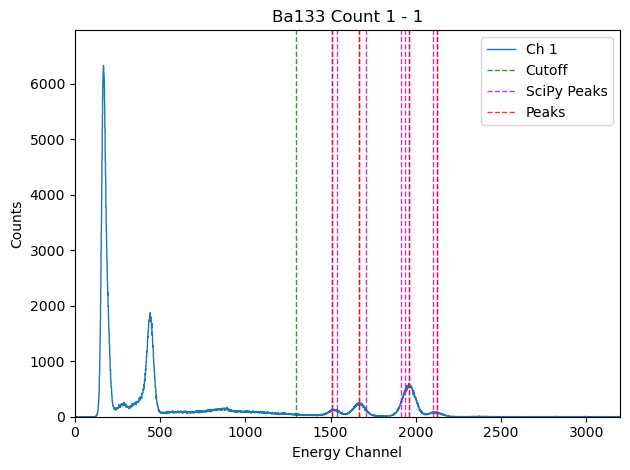

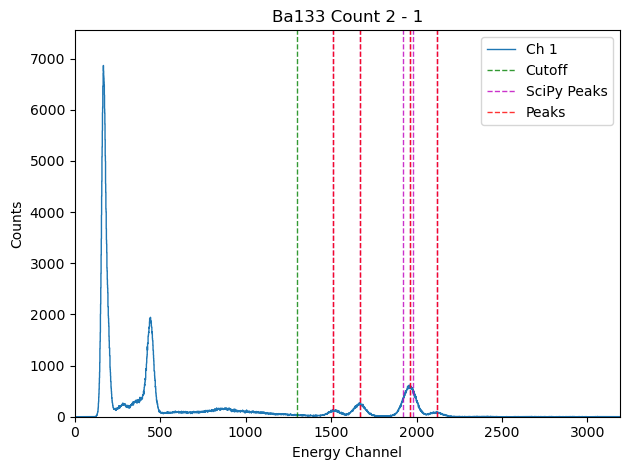

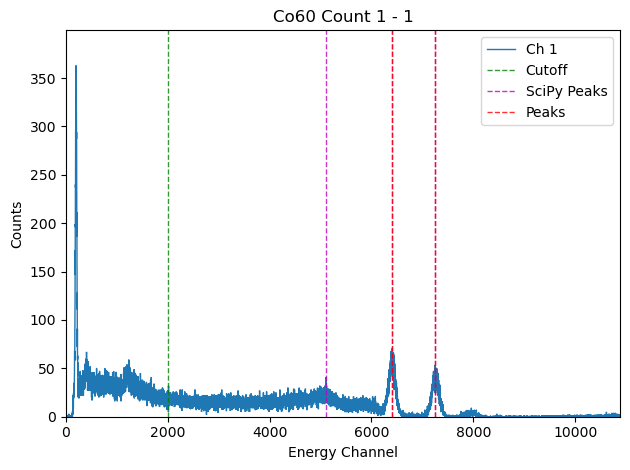

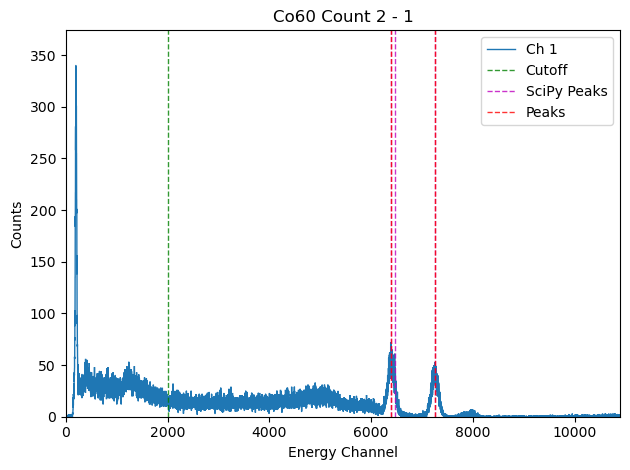

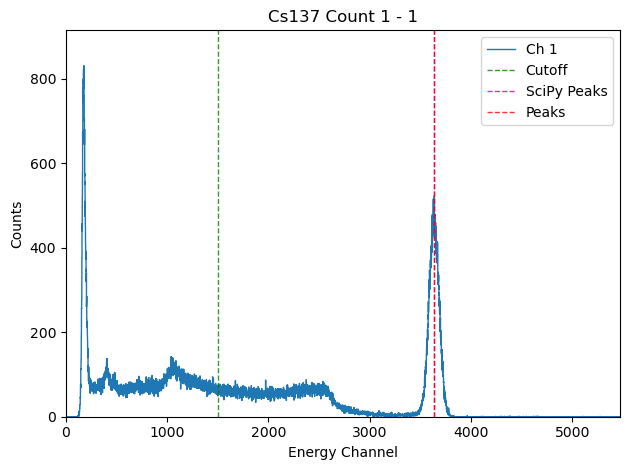

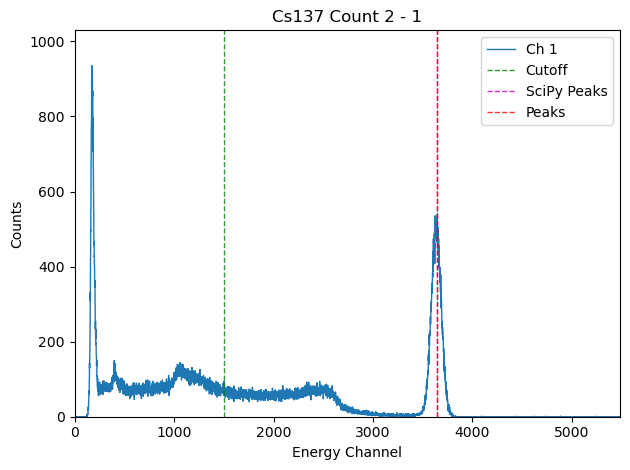

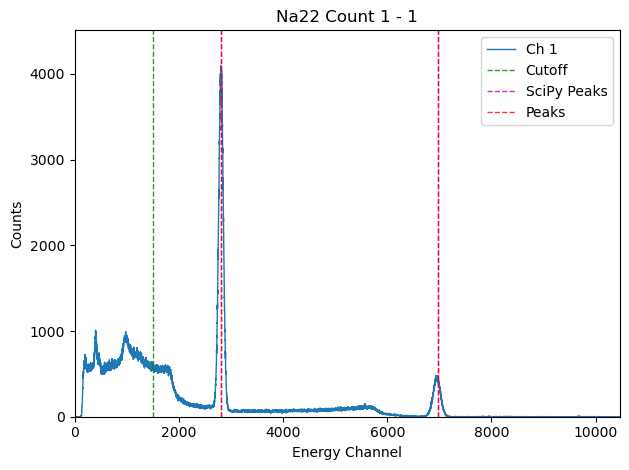

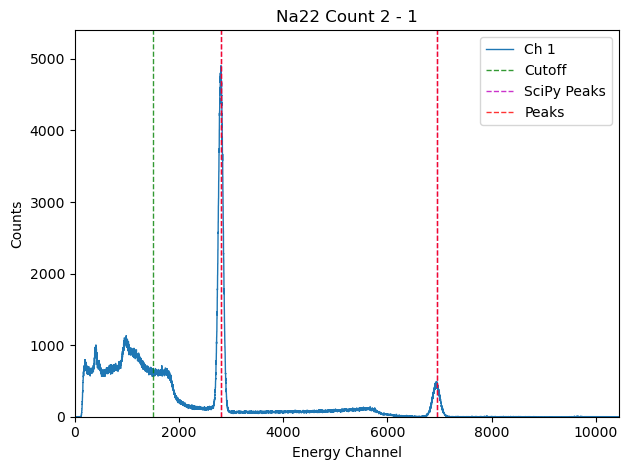

In [4]:
import matplotlib.pyplot as plt
from libra_toolbox.neutron_detection.activation_foils import compass
import scipy
print("Scipy version:", scipy.__version__)
from scipy.signal import find_peaks

calibration_channels = {}
calibration_energies = {}
for name, measurement in check_source_measurements.items():
    fig, ax = plt.subplots(nrows=1, ncols=len(measurement.detectors))
    if not isinstance(ax, np.ndarray):
        ax = [ax]
    for d,detector in enumerate(measurement.detectors):
        if detector.channel_nb not in calibration_channels:
            calibration_channels[detector.channel_nb] = []
            calibration_energies[detector.channel_nb] = []
        hist, bin_edges = detector.get_energy_hist()
        print(detector.nb_digitizer_bins)
        print(bin_edges)
        ax[d].stairs(
            hist, 
            bin_edges,
            label=f"Ch {detector.channel_nb}",
        )

        peak_kwargs = get_peak_kwargs(measurement.check_source.nuclide.name, 
                                        hist)
        if peak_kwargs:
            print("Scipy peak kwargs:")
            for k, v in peak_kwargs.items():
                print(f"  {k}: {v}")
            scipy_peak_inds, _ = find_peaks(hist[peak_kwargs["start_index"]:],
                                            prominence=peak_kwargs['prominence'],
                                            height=peak_kwargs['height'],
                                            distance=peak_kwargs['distance'],
                                            width=peak_kwargs['width'] if 'width' in peak_kwargs else None)
            scipy_peak_inds += peak_kwargs["start_index"]
            # peaks_ind = measurement.get_peaks(hist, **peak_kwargs)
        peaks_ind = measurement.get_peaks(hist)
        peaks = bin_edges[peaks_ind]

        if peak_kwargs:
            ax[d].vlines(bin_edges[peak_kwargs["start_index"]], 0, 1.1 * np.max(hist), 
                        colors='g', linestyles='dashed',
                        alpha=0.8, linewidth=1.0,
                        label='Cutoff')
            ax[d].vlines(bin_edges[scipy_peak_inds], 0, 1.1 * np.max(hist),
                        colors='m', linestyles='dashed',
                        alpha=0.8, linewidth=1.0,
                        label='SciPy Peaks')

        ax[d].vlines(peaks, 0, 1.1 * np.max(hist), 
                    colors='r', linestyles='dashed',
                    alpha=0.8, linewidth=1.0,
                    label='Peaks')
        
        ax[d].legend()
        ax[d].set_yscale("linear")
        ax[d].set_ylim(top=1.1 * np.max(hist))
        ax[d].set_title(f"{measurement.name} - {detector.channel_nb}")
        ax[d].set_xlabel("Energy Channel")
        ax[d].set_ylabel("Counts")
        ax[d].set_xlim(0, bin_edges[scipy_peak_inds[-1] + 10] * 1.5)

        if len(peaks) != len(measurement.check_source.nuclide.energy):
            print(f"Peaks found: {peaks}, expected: {measurement.check_source.nuclide.energy}")
            raise ValueError(
                f"SciPy find_peaks() found {len(peaks)} photon peaks, while {len(measurement.check_source.nuclide.energy)} were expected"
            )
        calibration_channels[detector.channel_nb] += list(peaks)
        calibration_energies[detector.channel_nb] += measurement.check_source.nuclide.energy

    fig.tight_layout()

for ch in calibration_channels.keys():
    inds = np.argsort(calibration_channels[ch])
    calibration_channels[ch] = np.array(calibration_channels[ch])[inds]
    calibration_energies[ch] = np.array(calibration_energies[ch])[inds]

plt.show()

In [5]:
calibration_channels = {}
calibration_energies = {}
for ch in [1]:
    calibration_channels[ch], calibration_energies[ch] = compass.get_calibration_data(check_source_measurements=check_source_measurements.values(),
                                                                                     background_measurement=background_meas,
                                                                                     channel_nb=ch)
    print("Calibration channels:", calibration_channels[ch])
    print("Calibration energies:", calibration_energies[ch])

Calibration channels: [1511 1512 1666 1671 1958 1960 2117 2122 2806 2806 3638 3647 6385 6408
 6950 6967 7243 7252]
Calibration energies: [ 276.3989  276.3989  302.8508  302.8508  356.0129  356.0129  383.8485
  383.8485  511.      511.      661.657   661.657  1173.228  1173.228
 1274.537  1274.537  1332.492  1332.492 ]


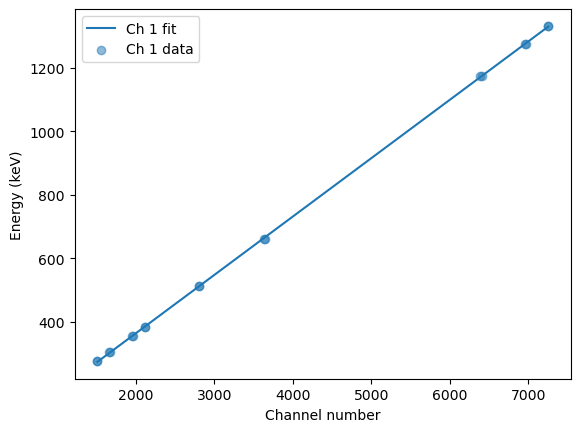

In [6]:
calibration_coeffs = {}

for channel_nb in [1]:


    coeff = np.polyfit(calibration_channels[channel_nb], calibration_energies[channel_nb], 1)
    calibration_coeffs[channel_nb] = coeff

    xs = np.linspace(
        calibration_channels[channel_nb][0],
        calibration_channels[channel_nb][-1],
    )
    plt.plot(
        xs,
        np.polyval(coeff, xs),
        label=f"Ch {channel_nb} fit",
    )
    plt.scatter(
        calibration_channels[channel_nb],
        calibration_energies[channel_nb],
        label=f"Ch {channel_nb} data",
        alpha=0.5,
    )
plt.xlabel("Channel number")
plt.ylabel("Energy (keV)")
plt.legend()
plt.show()

## Detector Efficiency

Using these same check-sources, each with a known activity, an efficiency curve for each detector is calculated. 

Two types of efficiency curves are shown: 
1. Exponent of sum of logarithms (used in https://doi.org/10.2172/1524045): $ y = \exp(\sum_{i=0}^n a_n \log(E)^i) $

2. Polynomial fit (3rd order): $ y = \sum_{i=0}^n a_n E^i $

**Only the polynomal fit is currently implemented in libra-toolbox, so that is the curve that will be used to calculate the efficiency of the detectors at measuring the activity of the activation foil peaks.**

## Bayesian Model with Preset Function

## Why Find the Peak of the Posterior Probability Distribution?

The **Maximum A Posteriori (MAP)** method finds the peak of the posterior probability distribution because **this peak represents the parameter values that are most consistent with both your data AND your prior knowledge**.

### The Intuitive Explanation

Imagine you're trying to estimate the efficiency parameters for your detector. You have:

1. **Your measured data**: Efficiency measurements at different energies (with uncertainties)
2. **Your prior knowledge**: Physical intuition about what reasonable parameter values should be

The posterior probability tells you: *"Given my prior beliefs and the data I just collected, how likely is each possible set of parameter values?"*

- **High probability** = These parameter values make sense given both physics and data
- **Low probability** = These parameter values either contradict the data or seem physically unreasonable

**The peak is where these two sources of information agree most strongly.**

### Why Not Just Fit the Data Without Priors?

Without priors (pure maximum likelihood), you might get:
- Parameter values that fit the data perfectly but are physically unrealistic
- Overfitting to noise in your measurements  
- Unstable results when you have limited data points

### Why Not Just Use Prior Knowledge Without Data?

Without considering the data, you'd just be guessing based on theory - you wouldn't learn anything from your actual measurements!

### The MAP Sweet Spot

The MAP estimate finds the **optimal balance** between:
- **Fitting your data well** (high likelihood)
- **Staying within reasonable bounds** (respecting priors)

### Real-World Example

In your efficiency fitting:
- Your **data** says: "At 600 keV, efficiency was 0.021 ± 0.0006"
- Your **prior** says: "Based on physics, I expect a₀ ≈ -2, a₁ ≈ 0.5"
- The **MAP** finds: "The parameters that best satisfy BOTH constraints simultaneously"

### What the Peak Tells You

The peak represents the **most credible parameter values** - if you had to make your best single guess about the true parameters, this would be it.

The **width of the peak** (which we estimate with the Hessian) tells you how confident you can be in this estimate:
- **Narrow peak** = High confidence, well-constrained parameters
- **Broad peak** = Lower confidence, parameters could vary more

This is why MAP is so powerful for scientific applications - it gives you both the best estimate AND a measure of how reliable that estimate is!

In [7]:
def eff_curve_func(E, *a):
    exponent_term = 0
    for i,a_n in enumerate(a):
        exponent_term += a_n * (np.log(E) ** i)
    return np.exp(exponent_term)

### The MAP Balancing Act

The key insight is that **finding the peak of the posterior probability distribution gives you the parameter values that represent the best compromise between your prior knowledge and your data**.

Here's why this matters specifically for your efficiency measurements:

#### The Three Alternatives and Their Problems:

1. **Pure Data Fitting (Maximum Likelihood Only)**
   - Problem: Might give physically unrealistic parameters
   - Example: Could suggest efficiency increases with energy (violates physics)

2. **Pure Prior Knowledge (Ignore Data)**
   - Problem: You learn nothing from your expensive measurements!
   - Example: Just assume efficiency follows some textbook curve

3. **Arbitrary Weighting**
   - Problem: How much should you trust data vs. prior knowledge?
   - Example: "I'll trust the data 70% and my prior 30%" - but why those numbers?

#### The MAP Solution:

The MAP method **automatically finds the optimal balance** using probability theory. The peak occurs where:

```
P(parameters | data, prior) ∝ P(data | parameters) × P(parameters)
                                    ↑                    ↑
                               Likelihood              Prior
```

- If your **data is very precise** (small error bars), the likelihood dominates → MAP trusts data more
- If your **data is noisy** (large error bars), the prior has more influence → MAP stays closer to physics intuition
- If your **prior is very certain** (narrow distribution), it constrains the result more
- If your **prior is vague** (wide distribution), the data drives the result

#### In Your Specific Case:

When you fit detector efficiency vs energy:
- **Data says**: "Here are my measured efficiencies with their uncertainties"
- **Prior says**: "Physics suggests a₀ should be around -2 (log-scale efficiency), a₁ should be positive (efficiency decreases with energy)"
- **MAP finds**: The parameter values that best satisfy both simultaneously

The peak represents the **most defensible scientific estimate** - it's the set of parameters you'd report in a paper because they're both consistent with your measurements AND physically reasonable.

The beauty of MAP is that it does this balancing act **objectively** using probability theory, rather than requiring you to make subjective judgments about how much to weight different sources of information.

measurement._uncalibrated_measured_energies: [np.int64(1511), np.int64(1666), np.int64(1958), np.int64(2122)]
[273.14133155 301.68394197 355.45453707 385.65446035]
Initial guess parameters: [0, 0, np.float64(135.63461604054152), np.float64(273.1413315526672), 4.166666666666667, np.float64(249.4546158131538), np.float64(301.683941966903), 4.166666666666667, np.float64(573.2496158700008), np.float64(355.45453706985035), 4.166666666666667, np.float64(90.70692343549604), np.float64(385.65446034684817), 4.166666666666667]
Plotting initial guess...
Plotting fitted curve...
Fitted parameters: [ 7.45417697e+01 -1.89812492e-01  9.58775403e+01  2.75163294e+02
  5.93349436e+00  2.20400483e+02  3.02045444e+02  6.14476541e+00
  5.53042454e+02  3.55944284e+02  6.76680501e+00  7.37016701e+01
  3.84502590e+02  6.93201578e+00]
Ba133 Count 1 Ch 1: Efficiency = [0.00093471 0.00086886 0.00070952 0.00067235] +/- [2.47882846e-05 1.49327718e-05 7.33627933e-06 1.88145959e-05]
measurement._uncalibrated_measure

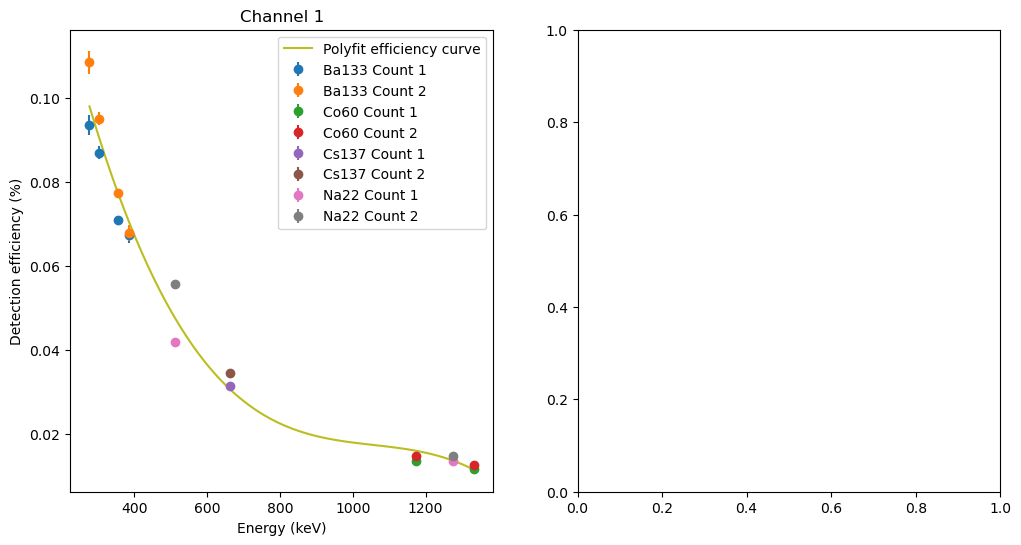

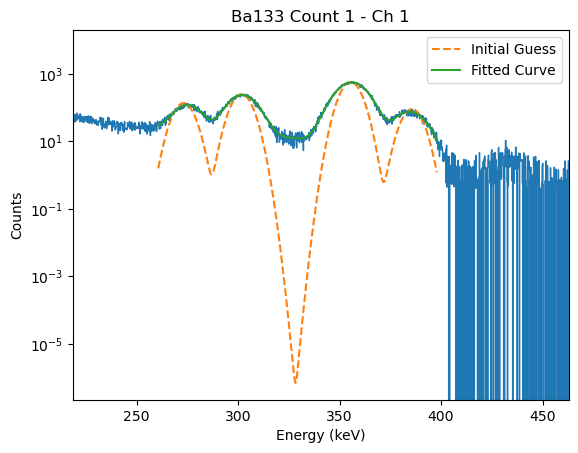

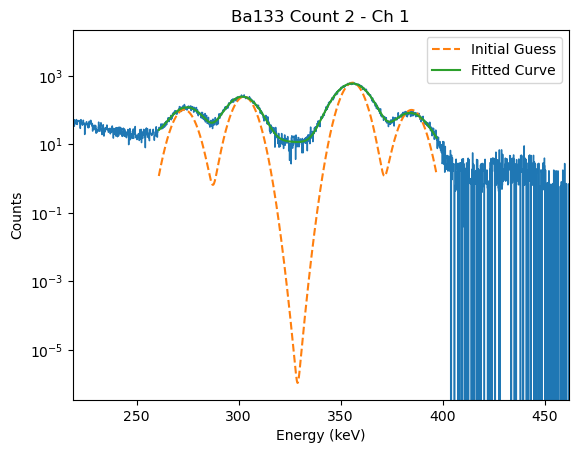

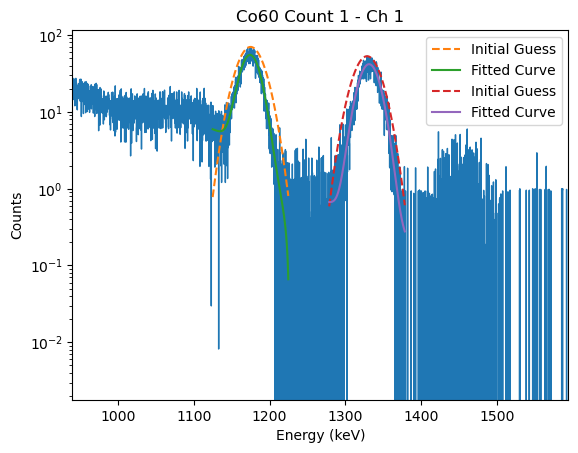

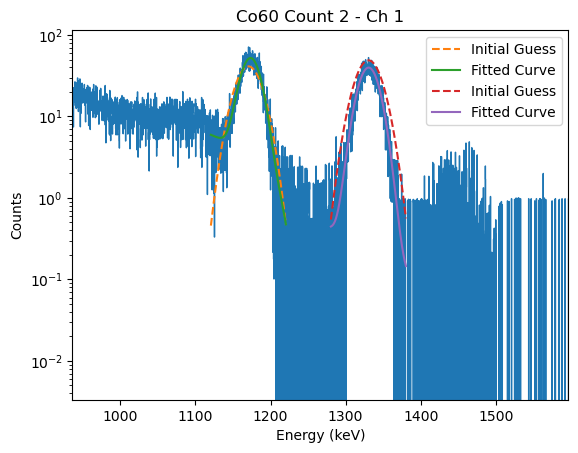

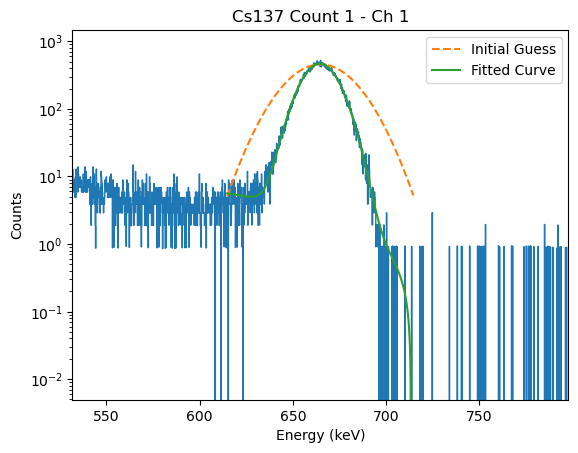

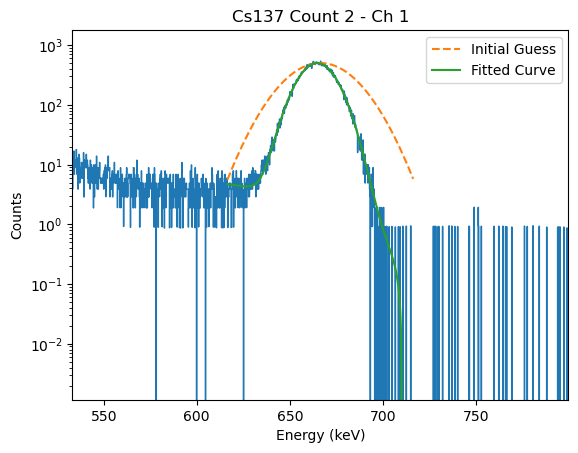

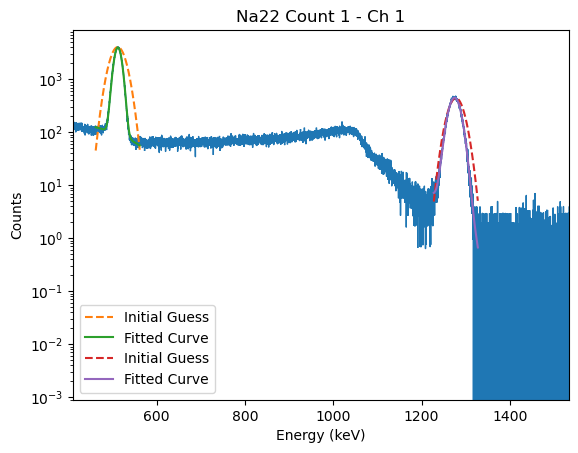

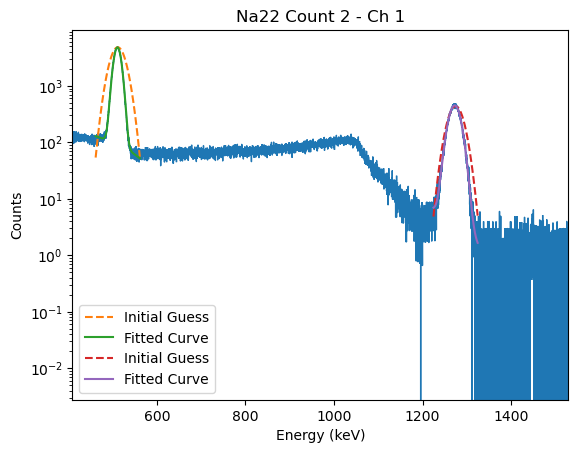

In [8]:
from scipy.optimize import curve_fit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel, Matern, RationalQuadratic, RBF
)

channels = []
efficiency_coeffs = {}

efficiency_dict = {}
efficiency_err_dict = {}
energy_dict = {}

measurement = list(check_source_measurements.values())[0]
search_width = 50

for detector in measurement.detectors:
    channels.append(detector.channel_nb)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
for i,ch in enumerate(channels):
    background_detector = background_meas.get_detector(ch)
    energies = []
    efficiencies = []
    eff_errs = []
    for name, measurement in check_source_measurements.items():
        check_source_detector = measurement.get_detector(ch)
        hist, bin_edges = check_source_detector.get_energy_hist_background_substract(background_detector)
        calibrated_bin_edges = np.polyval(calibration_coeffs[ch], bin_edges)
        fig_1, ax_1 = plt.subplots()
        ax_1.stairs(hist, calibrated_bin_edges)
        ax_1.set_title(f"{name} - Ch {ch}")
        ax_1.set_xlabel("Energy (keV)")
        ax_1.set_ylabel("Counts")

        print("measurement._uncalibrated_measured_energies:", measurement._uncalibrated_measured_energies[ch])
        peak_energies = measurement.get_calibrated_measured_energies(ch,
                                                                     calibration_coeffs=calibration_coeffs[ch])
        ax_1.set_xlim(peak_energies[0] * 0.8, peak_energies[-1] * 1.2)
        ax_1.set_yscale('log')
        
        efficiency, eff_err = measurement.compute_detection_efficiency(
            background_measurement=background_meas,
            calibration_coeffs=calibration_coeffs[ch],
            channel_nb=ch,
            search_width=search_width,
            compute_error=True,
            threshold_overlap=150,
            ax=ax_1
        )
        print(f"{name} Ch {ch}: Efficiency = {efficiency} +/- {eff_err}")

        energies += measurement.check_source.nuclide.energy
        efficiencies += list(efficiency)
        eff_errs += list(eff_err)
        ax[i].errorbar(
            measurement.check_source.nuclide.energy,
            efficiency * 100,
            yerr=eff_err * 100,
            label=name,
            fmt="o",
        )

    # Sort energies and efficiencies for fitting
    sorted_indices = np.argsort(energies)
    energies = np.array(energies)[sorted_indices]
    efficiencies = np.array(efficiencies)[sorted_indices]
    eff_errs = np.array(eff_errs)[sorted_indices]

    energy_dict[ch] = energies
    efficiency_dict[ch] = efficiencies
    efficiency_err_dict[ch] = eff_errs
    
    print(f"Ch {ch} \n\t Energies: {energies}, \n\t Efficiencies: {efficiencies}")

    # Fit the efficiency curve

    poly_coeff = np.polyfit(energies, efficiencies, 3)
    efficiency_coeffs[ch] = poly_coeff
    xs = np.linspace(
        energies[0],
        energies[-1],
        100,
    )

    ax[i].plot(
        xs,
        np.polyval(poly_coeff, xs) * 100,
        label="Polyfit efficiency curve",
    )
    ax[i].set_xlabel("Energy (keV)")
    ax[i].set_ylabel("Detection efficiency (%)")
    ax[i].set_title(f"Channel {ch}")
    ax[i].legend()
    # plt.ylim(bottom=0)

plt.show()


Processing Channel 1
MAP estimate: a0=-3.676, a1=0.246, a2=-0.179, a3=0.006
Parameter uncertainties: ±0.002, ±0.000, ±0.00005, ±0.00001


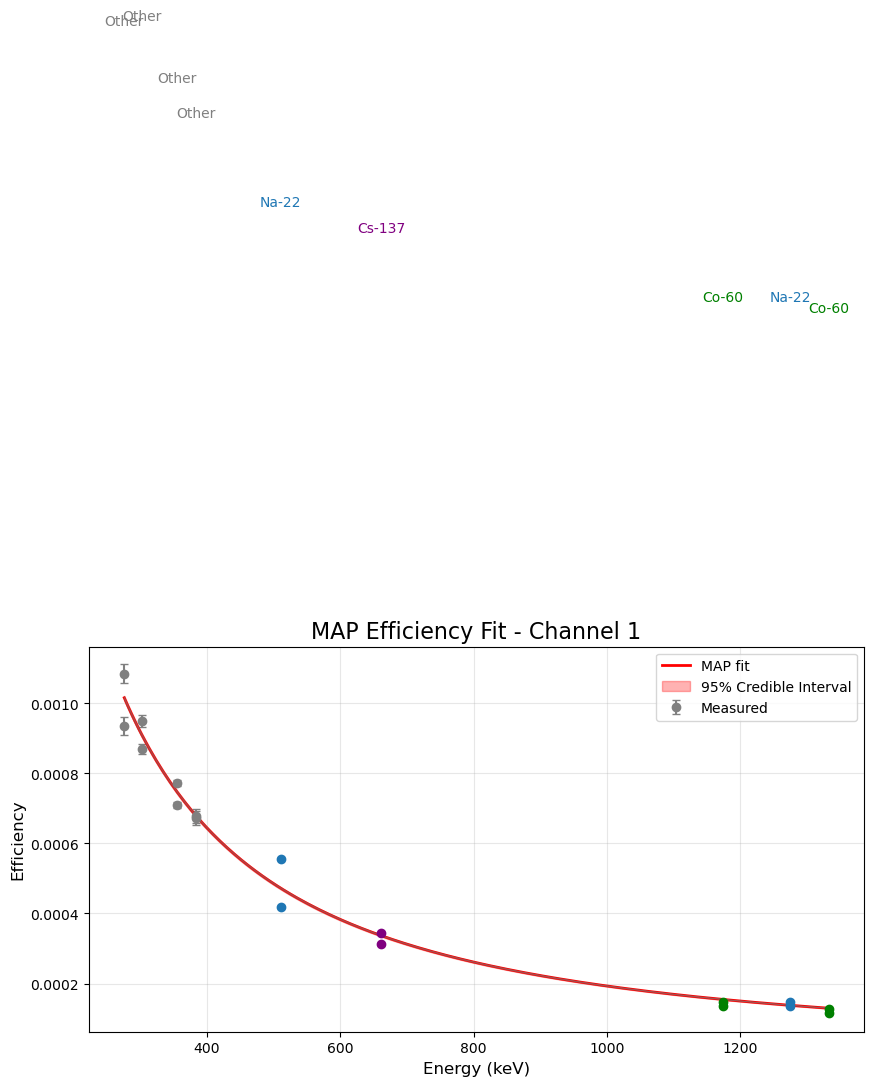


Posterior Summary for Channel 1:
Parameter  Mean       Std        2.5%       97.5%     
--------------------------------------------------
a0         -3.675     0.002      -3.679     -3.672    
a1         0.246      0.000      0.245      0.247     
a2         -0.179     0.000      -0.179     -0.179    
a3         0.006      0.000      0.006      0.006     

Bayesian-style fitting complete!


In [9]:
# Simplified Bayesian-style fitting without PyMC compilation issues
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings('ignore')

def negative_log_posterior(params, energies, efficiencies, eff_errs):
    """Negative log posterior for optimization"""
    a0, a1, a2, a3 = params
    
    # Priors (log normal distributions)
    log_prior = 0
    log_prior += -0.5 * ((a0 - (-2.0))/2.0)**2  # Prior centered at -2
    log_prior += -0.5 * ((a1 - 0.5)/1.0)**2     # Prior centered at 0.5  
    log_prior += -0.5 * ((a2 - 0.0)/0.5)**2     # Prior centered at 0
    log_prior += -0.5 * ((a3 - 0.0)/0.1)**2     # Prior centered at 0
    
    # Likelihood
    try:
        model_pred = eff_curve_func(energies, a0, a1, a2, a3)
        if np.any(np.isnan(model_pred)) or np.any(np.isinf(model_pred)) or np.any(model_pred <= 0):
            return 1e10
        residuals = (efficiencies - model_pred) / eff_errs
        log_likelihood = -0.5 * np.sum(residuals**2)
    except:
        return 1e10
    
    return -(log_prior + log_likelihood)

map_results = {}
# Process each channel
for ch in energy_dict.keys():
    print(f"\nProcessing Channel {ch}")
    
    energies = energy_dict[ch]
    efficiencies = efficiency_dict[ch]
    eff_errs = efficiency_err_dict[ch]
    
    # Find MAP (Maximum A Posteriori) estimate
    bounds = [(-10, 5), (-2, 3), (-1, 1), (-0.5, 0.5)]  # Reasonable bounds
    
    # Use differential evolution for global optimization
    result = differential_evolution(
        negative_log_posterior, 
        bounds, 
        args=(energies, efficiencies, eff_errs),
        seed=42,
        maxiter=1000,
        tol=1e-6
    )
    
    if result.success:
        map_params = result.x
        print(f"MAP estimate: a0={map_params[0]:.3f}, a1={map_params[1]:.3f}, a2={map_params[2]:.3f}, a3={map_params[3]:.3f}")
        
        # Estimate uncertainty using Hessian approximation
        from scipy.optimize import approx_fprime
        
        def neg_log_post_wrapper(params):
            return negative_log_posterior(params, energies, efficiencies, eff_errs)
        
        # Approximate the Hessian at MAP
        eps = 1e-5
        hess_diag = []
        for i in range(4):
            params_plus = map_params.copy()
            params_minus = map_params.copy()
            params_plus[i] += eps
            params_minus[i] -= eps
            
            second_deriv = (neg_log_post_wrapper(params_plus) - 
                          2*neg_log_post_wrapper(map_params) + 
                          neg_log_post_wrapper(params_minus)) / eps**2
            hess_diag.append(max(second_deriv, 1e-6))  # Ensure positive
        
        # Parameter uncertainties (diagonal approximation)
        param_stds = 1.0 / np.sqrt(np.array(hess_diag))
        
        print(f"Parameter uncertainties: ±{param_stds[0]:.3f}, ±{param_stds[1]:.3f}, ±{param_stds[2]:.5f}, ±{param_stds[3]:.5f}")
        
        # Store MAP results for later use
        map_results[ch] = {
            'params': map_params,
            'uncertainties': param_stds,
            'energy_range': (energies.min(), energies.max())
        }
        
        # Generate samples from approximate posterior (multivariate normal)
        cov_matrix = np.diag(param_stds**2)
        n_samples = 1000
        posterior_samples = multivariate_normal.rvs(
            mean=map_params, 
            cov=cov_matrix, 
            size=n_samples,
            random_state=42
        )
        
        # Plot results
        plt.figure(figsize=(10, 5))

        done_511 = 0
        done_1275 = 0
        done_662 = 0
        done_835 = 0
        done_1173 = 0
        done_1332 = 0
        # Plot data
        for i,data_i in enumerate(zip(energies, efficiencies, eff_errs)):
            energy, efficiency, eff_err = data_i
            if 500 < energy < 520:
                source_label = 'Na-22'
                source_color = 'tab:blue'
            elif 600 < energy < 700:
                source_label = 'Cs-137'
                source_color = 'purple'
            elif 800 < energy < 900:
                source_label = 'Mn-54'
                source_color = 'gray'
            elif 1100 < energy < 1200:
                source_label = 'Co-60'
                source_color = 'green'
            elif 1200 < energy < 1300:
                source_label = "Na-22"
                source_color = 'tab:blue'
            elif 1300 < energy < 1400:
                source_label = 'Co-60'
                source_color = 'green'
            else:
                source_label = 'Other'
                source_color = 'gray'
            if i==0:
                plot_label = "Measured"
            else:
                plot_label = None
            plt.errorbar(energy, efficiency, yerr=eff_err, fmt='o', label=plot_label, 
                         color=source_color, capsize=3, markersize=6)
            if np.mod(i,2)==0:
                plt.text(energy, efficiency + 0.002, source_label, color=source_color, 
                        fontsize=10, ha='center')
            

        # plt.errorbar(energies, efficiencies, yerr=eff_errs, fmt='o', 
        #             label='Data', capsize=3, markersize=6)
        
        # Plot MAP fit
        xs = np.linspace(energies.min(), energies.max(), 200)
        map_curve = eff_curve_func(xs, *map_params)
        plt.plot(xs, map_curve, 'r-', linewidth=2, label='MAP fit')
        
        # Plot uncertainty band using posterior samples
        curves = []
        for i in range(0, min(200, len(posterior_samples)), 5):
            try:
                curve = eff_curve_func(xs, *posterior_samples[i])
                if np.all(np.isfinite(curve)) and np.all(curve > 0):
                    curves.append(curve)
                    if len(curves) <= 20:  # Only plot first 20 for visibility
                        plt.plot(xs, curve, 'gray', alpha=0.1, linewidth=0.5)
            except:
                continue
        
        # Calculate credible interval
        if curves:
            curves = np.array(curves)
            lower = np.percentile(curves, 2.5, axis=0)
            upper = np.percentile(curves, 97.5, axis=0)
            plt.fill_between(xs, lower, upper, alpha=0.3, color='red', 
                           label='95% Credible Interval')
        
        plt.xlabel('Energy (keV)', fontsize=12)
        plt.ylabel('Efficiency', fontsize=12)
        plt.title(f'MAP Efficiency Fit - Channel {ch}', fontsize=16)
        plt.legend()
        plt.grid(True, alpha=0.3)
        # plt.ylim(0.005, np.max(efficiencies)*1.2)
        plt.savefig(f'efficiency_fit_channel_{ch}.png', dpi=300)
        plt.show()
        
        # Summary statistics
        print(f"\nPosterior Summary for Channel {ch}:")
        param_names = ['a0', 'a1', 'a2', 'a3']
        print(f"{'Parameter':<10} {'Mean':<10} {'Std':<10} {'2.5%':<10} {'97.5%':<10}")
        print("-" * 50)
        for i, name in enumerate(param_names):
            samples_i = posterior_samples[:, i]
            mean_val = np.mean(samples_i)
            std_val = np.std(samples_i)
            q025 = np.percentile(samples_i, 2.5)
            q975 = np.percentile(samples_i, 97.5)
            print(f"{name:<10} {mean_val:<10.3f} {std_val:<10.3f} {q025:<10.3f} {q975:<10.3f}")
    
    else:
        print(f"Optimization failed for channel {ch}")
        print("Falling back to simple curve_fit...")
        
        # Fallback to scipy curve_fit
        from scipy.optimize import curve_fit
        try:
            popt, pcov = curve_fit(eff_curve_func, energies, efficiencies, 
                                 sigma=eff_errs, p0=[-2, 0.5, 0, 0])
            param_errs = np.sqrt(np.diag(pcov))
            
            plt.figure(figsize=(10, 6))
            plt.errorbar(energies, efficiencies, yerr=eff_errs, fmt='o', 
                        label='Data', capsize=3)
            xs = np.linspace(energies.min(), energies.max(), 200)
            plt.plot(xs, eff_curve_func(xs, *popt), 'r-', linewidth=2, 
                    label='Curve fit')
            plt.xlabel('Energy (keV)')
            plt.ylabel('Efficiency')
            plt.title(f'Fallback Curve Fit - Channel {ch}')
            plt.legend()
            plt.show()
            
            print(f"Fitted parameters: a0={popt[0]:.3f}±{param_errs[0]:.3f}, "
                  f"a1={popt[1]:.3f}±{param_errs[1]:.3f}, "
                  f"a2={popt[2]:.3f}±{param_errs[2]:.3f}, "
                  f"a3={popt[3]:.3f}±{param_errs[3]:.3f}")
        except Exception as e:
            print(f"Even curve_fit failed: {e}")

print("\nBayesian-style fitting complete!")

In [10]:
# Function to calculate efficiency and uncertainty at arbitrary energies
def calculate_efficiency_at_energy(energy, channel, method='propagation'):
    """
    Calculate efficiency and 1-sigma uncertainty at a given energy using MAP results
    
    Parameters:
    -----------
    energy : float or array
        Energy value(s) in keV where you want to calculate efficiency
    channel : int 
        Channel number (4 or 5)
    method : str
        'propagation' for analytical uncertainty propagation
        'sampling' for Monte Carlo sampling approach
        
    Returns:
    --------
    efficiency : float or array
        Predicted efficiency value(s)
    uncertainty : float or array  
        1-sigma uncertainty in efficiency
    """
    
    # Check if we have MAP results for this channel
    if channel not in map_results:
        raise ValueError(f"No MAP results available for channel {channel}. Run the Bayesian fitting first.")
    
    map_params = map_results[channel]['params']
    param_stds = map_results[channel]['uncertainties']
    
    # Convert energy to array for consistent handling
    energy = np.atleast_1d(energy)
    
    # Calculate efficiency using MAP parameters
    efficiency = eff_curve_func(energy, *map_params)
    
    if method == 'propagation':
        # Analytical uncertainty propagation using partial derivatives
        # For f(E) = exp(a0 + a1*ln(E) + a2*ln(E)^2 + a3*ln(E)^3)
        # df/da_i = f(E) * ln(E)^i
        
        log_E = np.log(energy)
        
        # Partial derivatives
        df_da0 = efficiency  # df/da0 = f(E)
        df_da1 = efficiency * log_E  # df/da1 = f(E) * ln(E)
        df_da2 = efficiency * log_E**2  # df/da2 = f(E) * ln(E)^2  
        df_da3 = efficiency * log_E**3  # df/da3 = f(E) * ln(E)^3
        
        # Uncertainty propagation: sigma_f^2 = sum((df/da_i)^2 * sigma_a_i^2)
        uncertainty_squared = (
            (df_da0 * param_stds[0])**2 + 
            (df_da1 * param_stds[1])**2 + 
            (df_da2 * param_stds[2])**2 + 
            (df_da3 * param_stds[3])**2
        )
        uncertainty = np.sqrt(uncertainty_squared)
        
    elif method == 'sampling':
        # Monte Carlo sampling approach
        n_samples = 1000
        cov_matrix = np.diag(param_stds**2)
        
        # Generate parameter samples
        param_samples = np.random.multivariate_normal(
            map_params, cov_matrix, size=n_samples
        )
        
        # Calculate efficiency for each parameter sample
        efficiency_samples = []
        for params in param_samples:
            try:
                eff_sample = eff_curve_func(energy, *params)
                if np.all(np.isfinite(eff_sample)) and np.all(eff_sample > 0):
                    efficiency_samples.append(eff_sample)
            except:
                continue
                
        if efficiency_samples:
            efficiency_samples = np.array(efficiency_samples)
            # Use the mean and std of samples
            efficiency = np.mean(efficiency_samples, axis=0)
            uncertainty = np.std(efficiency_samples, axis=0)
        else:
            # Fallback to propagation method
            return calculate_efficiency_at_energy(energy, channel, method='propagation')
    
    # Return scalar if input was scalar
    if len(energy) == 1:
        return float(efficiency[0]), float(uncertainty[0])
    else:
        return efficiency, uncertainty


print("Efficiency calculation function defined. Run the Bayesian fitting to populate map_results.")

Efficiency calculation function defined. Run the Bayesian fitting to populate map_results.


## Uncertainty Quantification: Propagation vs. Sampling

The `calculate_efficiency_at_energy()` function offers two methods for estimating uncertainties. Here's a detailed comparison:

### Method 1: Analytical Error Propagation ('propagation')

**How it works:**
- Uses partial derivatives to compute how uncertainties in parameters translate to uncertainties in predictions
- Formula: `σ_f² = Σ(∂f/∂a_i)² × σ_a_i²`
- For our efficiency function: `f(E) = exp(a₀ + a₁ln(E) + a₂ln²(E) + a₃ln³(E))`

**Pros:**
- **Fast**: Analytical calculation, no Monte Carlo sampling needed
- **Exact**: Gives the mathematically correct uncertainty (for linear approximation)
- **Deterministic**: Always gives the same result
- **Memory efficient**: No need to store thousands of samples
- **Good for real-time applications**: Instant results

**Cons:**
- **Linear approximation**: Only accurate when the function is approximately linear near the MAP estimate
- **Assumes Gaussian uncertainties**: May underestimate uncertainties if parameter distributions are non-Gaussian
- **No correlation information**: Our implementation assumes parameters are uncorrelated
- **Can fail for highly nonlinear functions**: May give poor estimates if efficiency function has strong curvature

**Best for:** Most routine calculations, when you need fast results, when parameter uncertainties are small relative to the function's curvature.

### Method 2: Monte Carlo Sampling ('sampling')

**How it works:**
- Generates many random parameter sets from the posterior distribution
- Calculates efficiency for each parameter set
- Uses the standard deviation of these predictions as the uncertainty estimate

**Pros:**
- **Handles nonlinearity**: Captures the true uncertainty even for highly nonlinear functions
- **No mathematical approximations**: Directly samples from the posterior
- **Captures asymmetric uncertainties**: Can detect if uncertainty is larger in one direction
- **Can include correlations**: Easy to extend to include parameter correlations
- **Robust**: Works for any function, no matter how complex

**Cons:**
- **Slower**: Requires generating and evaluating many samples (typically 1000+)
- **Stochastic**: Results vary slightly between runs due to random sampling
- **Memory intensive**: Must store parameter samples
- **Assumes correct posterior approximation**: Only as good as your parameter uncertainty estimates

**Best for:** When you suspect strong nonlinearities, want to capture asymmetric uncertainties, or need the most robust uncertainty estimate.

### When to Use Which Method?

**Use Propagation when:**
- You need fast, routine calculations
- Parameter uncertainties are small (< 10% of parameter values)
- The efficiency function is reasonably smooth and linear locally
- You're doing many repeated calculations

**Use Sampling when:**
- You want the most robust uncertainty estimate
- You suspect the efficiency function has strong curvature
- Parameter uncertainties are large
- You're doing a final, high-precision analysis
- You want to check if propagation results are reliable

### For Your Efficiency Curves:

In your case, the efficiency function `exp(a₀ + a₁ln(E) + ...)` is moderately nonlinear, but your MAP parameter uncertainties are quite small (σ ~ 0.01 for most parameters). This suggests:

- **Propagation should be quite accurate** for most purposes
- **Sampling provides a good cross-check** to verify propagation results
- **Both methods should give similar results** if the linear approximation is valid

### Quick Comparison Test:

You can easily compare both methods as shown below.  If the difference is < 5%, propagation is likely sufficient. If > 20%, the nonlinearity is significant and sampling is more trustworthy.

In [11]:
# Compare methods for a specific energy
energy = 900  # keV
eff_prop, unc_prop = calculate_efficiency_at_energy(energy, 1, method='propagation')
eff_samp, unc_samp = calculate_efficiency_at_energy(energy, 1, method='sampling')

print(f"Propagation: {eff_prop:.6f} ± {unc_prop:.6f}")
print(f"Sampling:    {eff_samp:.6f} ± {unc_samp:.6f}")
print(f"Difference:  {abs(unc_prop - unc_samp)/unc_prop*100:.1f}%")

Propagation: 0.000223 ± 0.000001
Sampling:    0.000223 ± 0.000001
Difference:  1.7%


In [12]:
# Practical comparison of propagation vs. sampling methods
if map_results:  # Only run if we have MAP results
    print("=== COMPARISON: Propagation vs. Sampling Methods ===\n")
    
    # Test energies spanning the fitted range
    test_energies = [600, 750, 900, 1050, 1200]
    
    for ch in map_results.keys():
        print(f"Channel {ch}:")
        print(f"{'Energy (keV)':<12} {'Method':<12} {'Efficiency':<12} {'Uncertainty':<12} {'Rel. Unc. (%)':<12}")
        print("-" * 65)
        
        for energy in test_energies:
            energy_range = map_results[ch]['energy_range']
            if energy_range[0] <= energy <= energy_range[1]:
                
                # Propagation method
                eff_prop, unc_prop = calculate_efficiency_at_energy(energy, ch, method='propagation')
                rel_unc_prop = unc_prop / eff_prop * 100
                
                # Sampling method
                eff_samp, unc_samp = calculate_efficiency_at_energy(energy, ch, method='sampling')
                rel_unc_samp = unc_samp / eff_samp * 100
                
                # Display results
                print(f"{energy:<12.0f} {'Propagation':<12} {eff_prop:<12.6f} {unc_prop:<12.6f} {rel_unc_prop:<12.1f}")
                print(f"{'':<12} {'Sampling':<12} {eff_samp:<12.6f} {unc_samp:<12.6f} {rel_unc_samp:<12.1f}")
                
                # Calculate difference
                unc_diff_pct = abs(unc_prop - unc_samp) / unc_prop * 100
                eff_diff_pct = abs(eff_prop - eff_samp) / eff_prop * 100
                
                print(f"{'':<12} {'Difference':<12} {eff_diff_pct:<11.3f}% {unc_diff_pct:<11.3f}%")
                print()
        
        print()
    
    
    # Summary assessment
    print("=== ASSESSMENT ===")
    print("If the uncertainty bands largely overlap and differences are < 5%:")
    print("→ Propagation method is sufficiently accurate")
    print("\nIf differences are 5-20%:")
    print("→ Moderate nonlinearity present, consider sampling for important calculations")
    print("\nIf differences are > 20%:")
    print("→ Strong nonlinearity, use sampling method for reliable uncertainties")
    
else:
    print("No MAP results available. Please run the Bayesian fitting first.")

=== COMPARISON: Propagation vs. Sampling Methods ===

Channel 1:
Energy (keV) Method       Efficiency   Uncertainty  Rel. Unc. (%)
-----------------------------------------------------------------
600          Propagation  0.000383     0.000002     0.4         
             Sampling     0.000383     0.000001     0.4         
             Difference   0.014      % 1.512      %

750          Propagation  0.000285     0.000001     0.4         
             Sampling     0.000285     0.000001     0.4         
             Difference   0.004      % 3.977      %

900          Propagation  0.000223     0.000001     0.4         
             Sampling     0.000223     0.000001     0.4         
             Difference   0.001      % 2.511      %

1050         Propagation  0.000180     0.000001     0.5         
             Sampling     0.000180     0.000001     0.4         
             Difference   0.016      % 1.560      %

1200         Propagation  0.000150     0.000001     0.5         
      

Examples of calculating efficiency at arbitrary energies:

Channel 1 (valid range: 276 - 1332 keV)
  At 600 keV: efficiency = 0.000383 ± 0.000002 (0.4%)
  At 750 keV: efficiency = 0.000285 ± 0.000001 (0.4%)
  At 900 keV: efficiency = 0.000223 ± 0.000001 (0.4%)
  At 1000 keV: efficiency = 0.000193 ± 0.000001 (0.4%)
  At 1200 keV: efficiency = 0.000150 ± 0.000001 (0.5%)

Plotting efficiency curves with uncertainty bands:


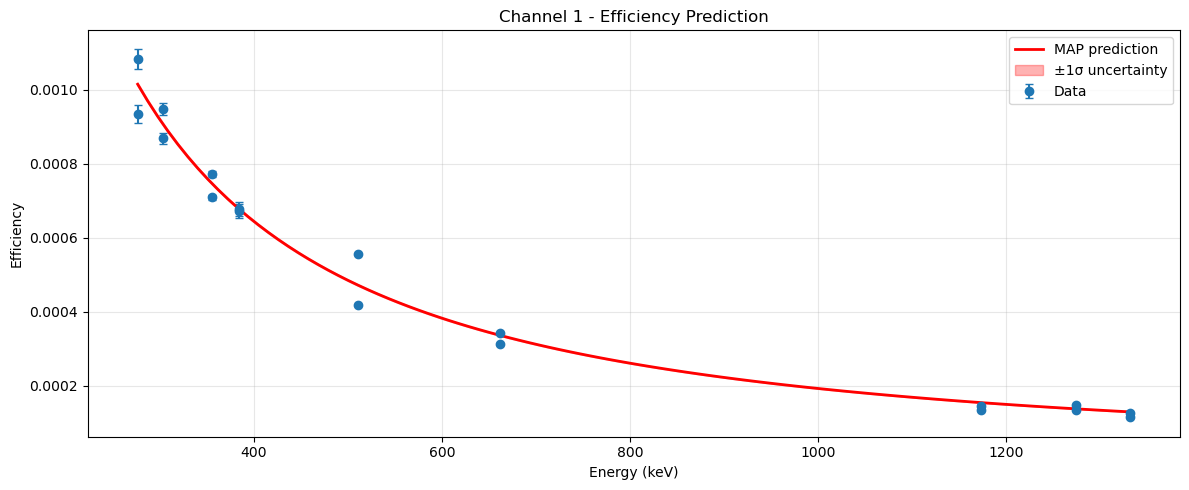

In [13]:
# Example: Calculate efficiency at specific energies
# (Run this after the Bayesian fitting above)

if map_results:  # Only run if we have MAP results
    print("Examples of calculating efficiency at arbitrary energies:\n")
    
    for ch in map_results.keys():
        energy_range = map_results[ch]['energy_range']
        print(f"Channel {ch} (valid range: {energy_range[0]:.0f} - {energy_range[1]:.0f} keV)")
        
        # Example energies within the fitted range
        test_energies = [600, 750, 900, 1000, 1200]
        
        for energy in test_energies:
            if energy_range[0] <= energy <= energy_range[1]:  # Check if within fitted range
                eff, eff_err = calculate_efficiency_at_energy(energy, ch, method='propagation')
                print(f"  At {energy} keV: efficiency = {eff:.6f} ± {eff_err:.6f} ({eff_err/eff*100:.1f}%)")
        
        print()
    
    # Example: Calculate efficiency curve with uncertainties
    print("Plotting efficiency curves with uncertainty bands:")
    
    fig, axes = plt.subplots(1, len(map_results), figsize=(12, 5))
    if len(map_results) == 1:
        axes = [axes]
    
    for i, ch in enumerate(map_results.keys()):
        energy_range = map_results[ch]['energy_range']
        
        # Create fine energy grid
        energy_grid = np.linspace(energy_range[0], energy_range[1], 100)
        
        # Calculate efficiencies and uncertainties
        eff_pred, eff_unc = calculate_efficiency_at_energy(energy_grid, ch, method='propagation')
        
        # Plot original data
        energies = energy_dict[ch]
        efficiencies = efficiency_dict[ch]
        eff_errs = efficiency_err_dict[ch]
        
        axes[i].errorbar(energies, efficiencies, yerr=eff_errs, fmt='o', 
                        label='Data', capsize=3, markersize=6)
        
        # Plot MAP prediction with uncertainty band
        axes[i].plot(energy_grid, eff_pred, 'r-', linewidth=2, label='MAP prediction')
        axes[i].fill_between(energy_grid, 
                            eff_pred - eff_unc, 
                            eff_pred + eff_unc,
                            alpha=0.3, color='red', label='±1σ uncertainty')
        
        axes[i].set_xlabel('Energy (keV)')
        axes[i].set_ylabel('Efficiency')
        axes[i].set_title(f'Channel {ch} - Efficiency Prediction')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No MAP results found. Please run the Bayesian fitting cell first.")

## Calculating average neutron rate from activation foils

First, the irradiation schedule and the foil information is collected.

Foil: Copper-1
{'measurement_paths': {1: PosixPath('../../data/LaBr/ngen_charac2_LaBr_Paul_25Feb2026/DAQ/Copper1_90deg_LaBr_count1/UNFILTERED')}, 'foil': ActivationFoil(reaction=Reaction(reactant=Nuclide(name='Cu65', energy=None, intensity=None, half_life=None, atomic_mass=64.9278, abundance=0.3085), product=Nuclide(name='Cu64', energy=[511, 1345.77], intensity=[0.21531999999999998, 0.2903744], half_life=None, atomic_mass=63.9298, abundance=1.0), cross_section=array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.0388762 ,
       0.27003033, 0.58151387, 0.78989771, 0.9348801 ])), mass=0.4112, name='Copper-1', density=8.96, thickness=0.02286), 'distance_to_source': 12.0, 'measurements': {1: <libra_toolbox.neutron_detection.activation_foils.compass.SampleMeasurement object at 0x7fb527d32900>}}
  Measurement: 1


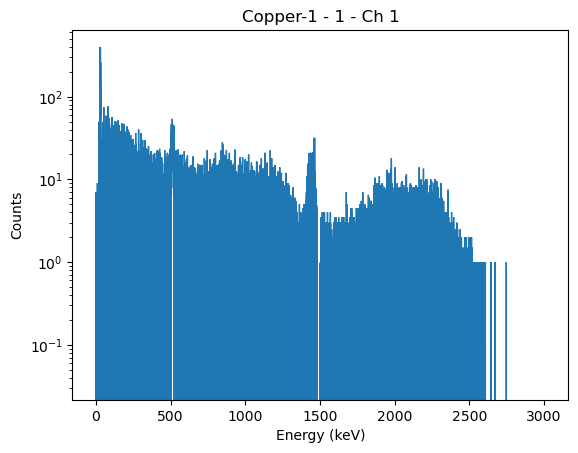

Foil: Niobium-13
{'measurement_paths': {1: PosixPath('../../data/LaBr/20260225_nGen_charac2_LaBr_Dunn/DAQ/Niobium13_180deg_count2/UNFILTERED')}, 'foil': ActivationFoil(reaction=Reaction(reactant=Nuclide(name='Nb93', energy=None, intensity=None, half_life=None, atomic_mass=92.90637, abundance=1.0), product=Nuclide(name='Nb92m', energy=[934.44], intensity=[0.9915], half_life=885600.0, atomic_mass=None, abundance=1.0), cross_section=4.5966e-25), mass=1.1285, name='Niobium-13', density=8.582, thickness=0.050800000000000005), 'distance_to_source': 12.0, 'measurements': {1: <libra_toolbox.neutron_detection.activation_foils.compass.SampleMeasurement object at 0x7fb527a88690>}}
  Measurement: 1


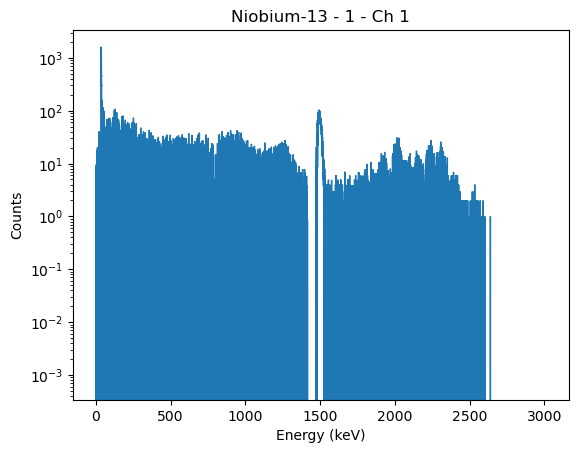

In [17]:
for name, foil_dict in foil_measurements.items():
    print(f"Foil: {name}")
    print(foil_dict)
    for meas_name, measurement in foil_dict["measurements"].items():
        print(f"  Measurement: {meas_name}")
        for det in measurement.detectors:
            hist, bin_edges = det.get_energy_hist_background_substract(background_meas.get_detector(det.channel_nb))
            calibrated_bin_edges = np.polyval(calibration_coeffs[det.channel_nb], bin_edges)
            plt.figure()
            plt.stairs(hist, calibrated_bin_edges)
            plt.title(f"{name} - {meas_name} - Ch {det.channel_nb}")
            plt.xlabel("Energy (keV)")
            plt.ylabel("Counts")
            plt.yscale('log')
            plt.show()

In [15]:
from process_foil_data import irradiations, time_generator_off

### Niobium Packet #3 Results

The activity of Nb-92m is measured using its 934 keV gamma peak and used to determine the neutron rate during the irradiation. Nb-92m is formed from the Nb-93(n,2n) reaction, which has a threshold energy of 8.9 MeV. 

The gamma spectrum obtained from the various measurements of the Niobium Packet #3 after irradiation are used to calculate the neutron rate of the overall irradiation. 

Add the one-group cross sections from the simulation results using the IRDF-II cross section database

In [ ]:
# from process_foil_data import calculate_xs_from_sim
# foil_measurements = calculate_xs_from_sim(foil_measurements)

ImportError: cannot import name 'calculate_xs_from_sim' from 'process_foil_data' (/home/cdunn314/libra/ngen_characterization_v2/analysis/foils/process_foil_data.py)

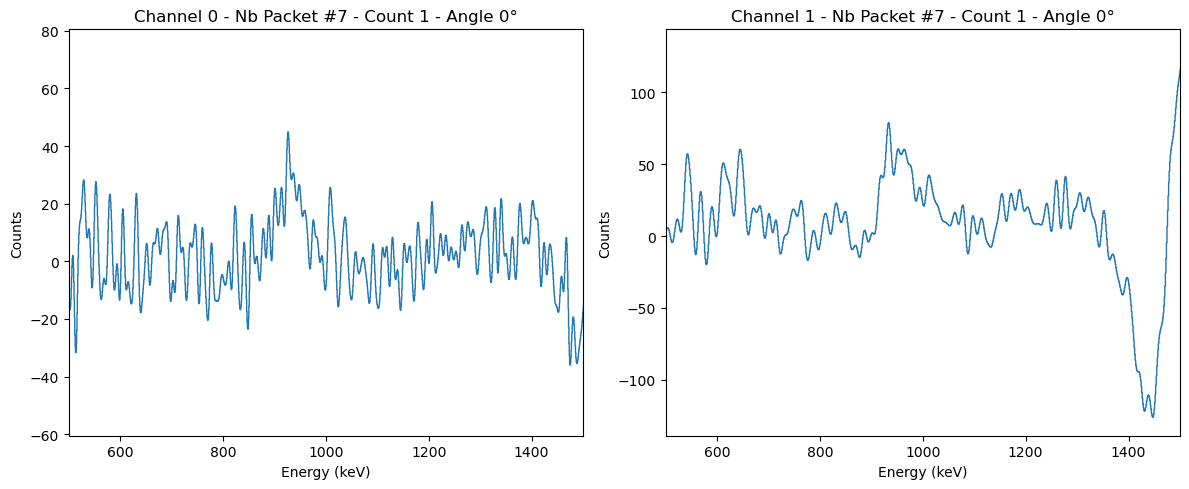

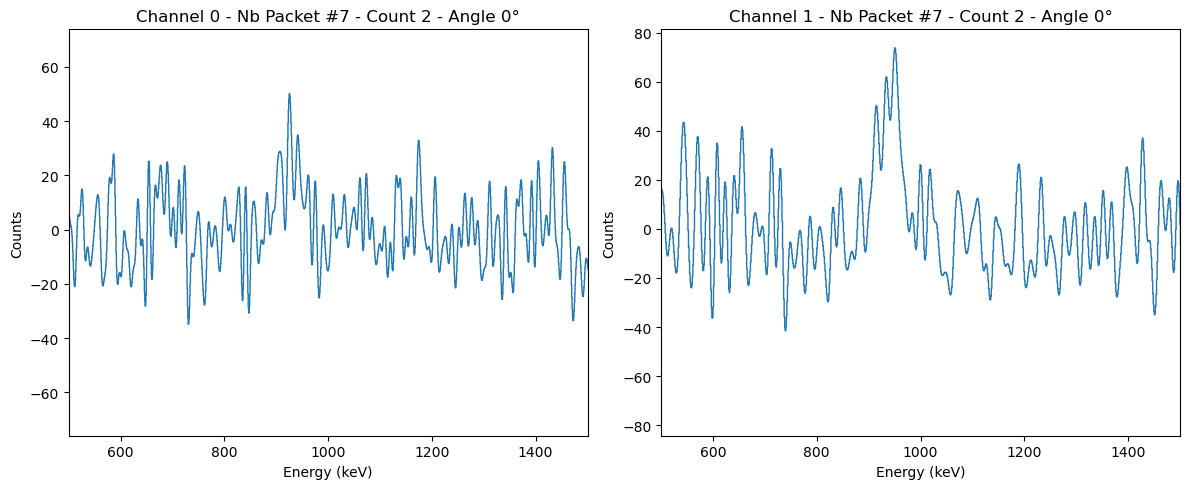

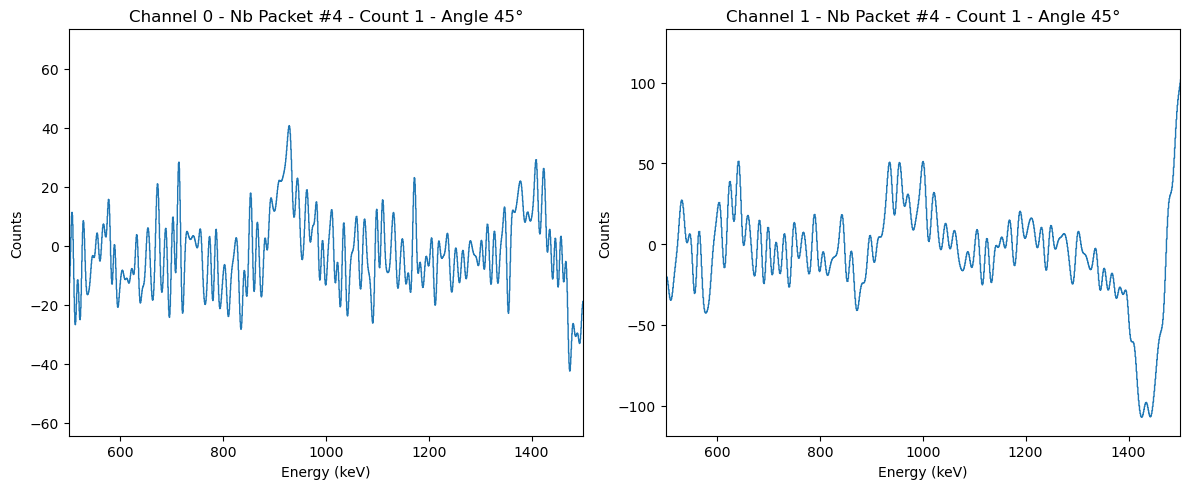

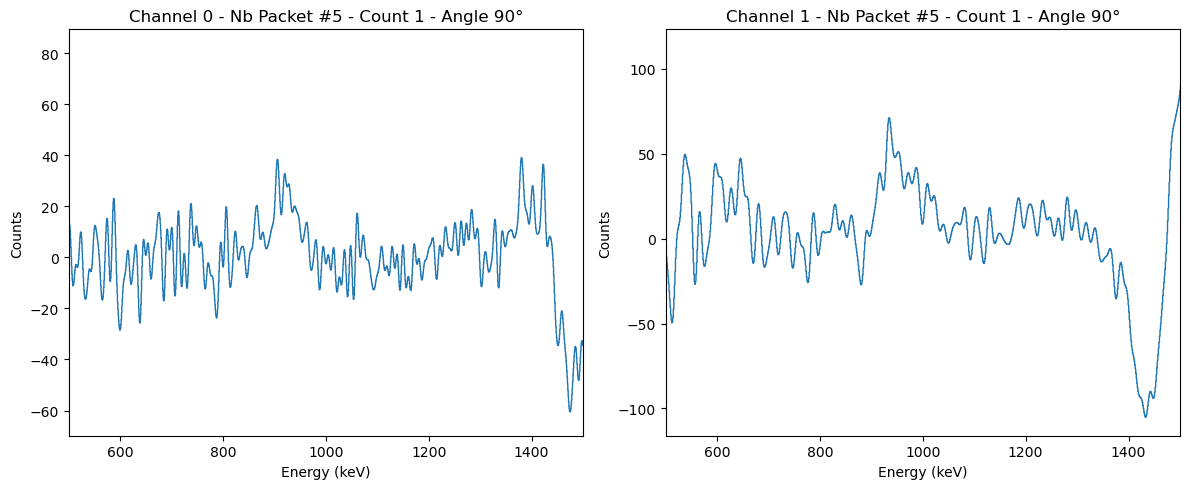

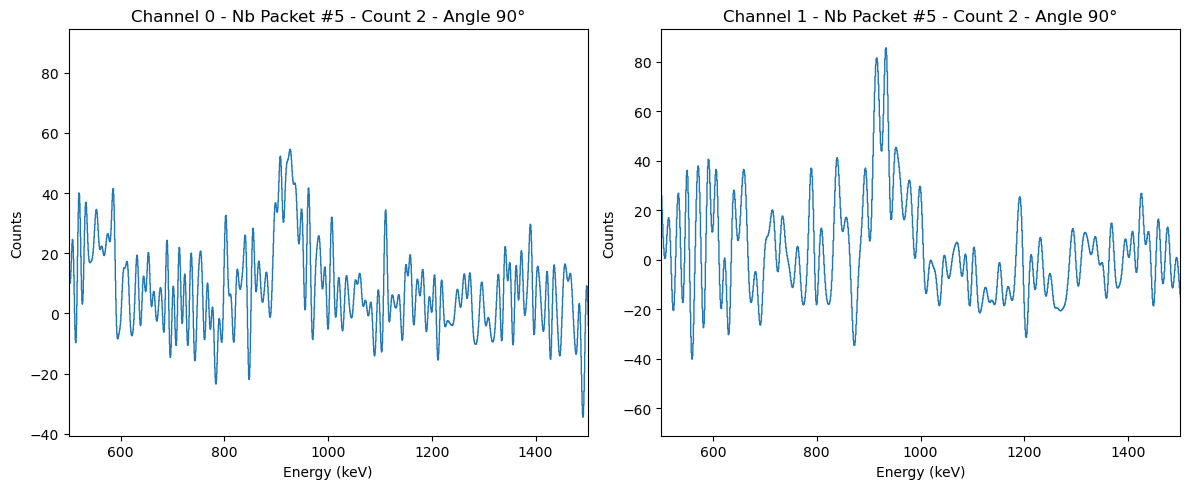

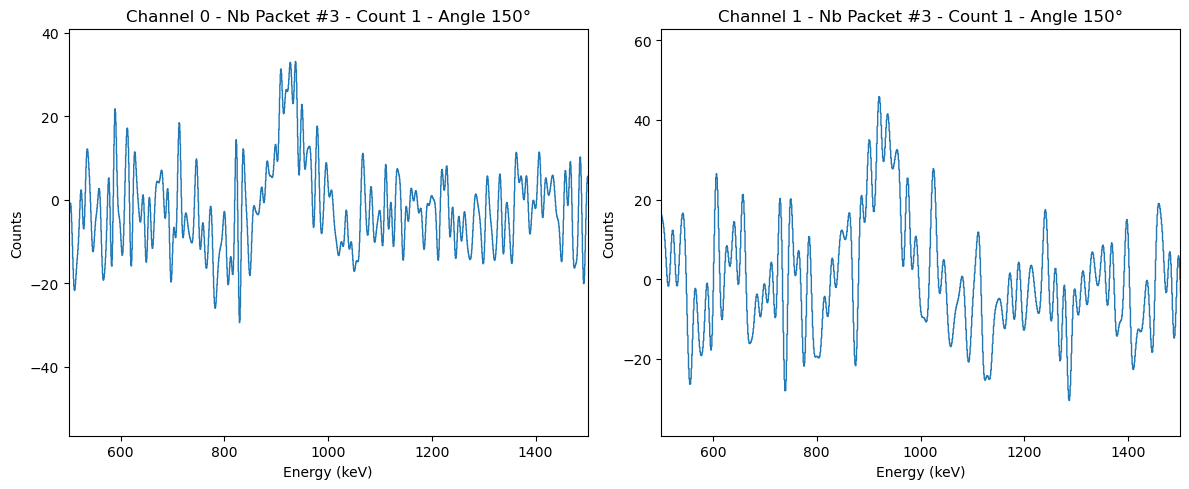

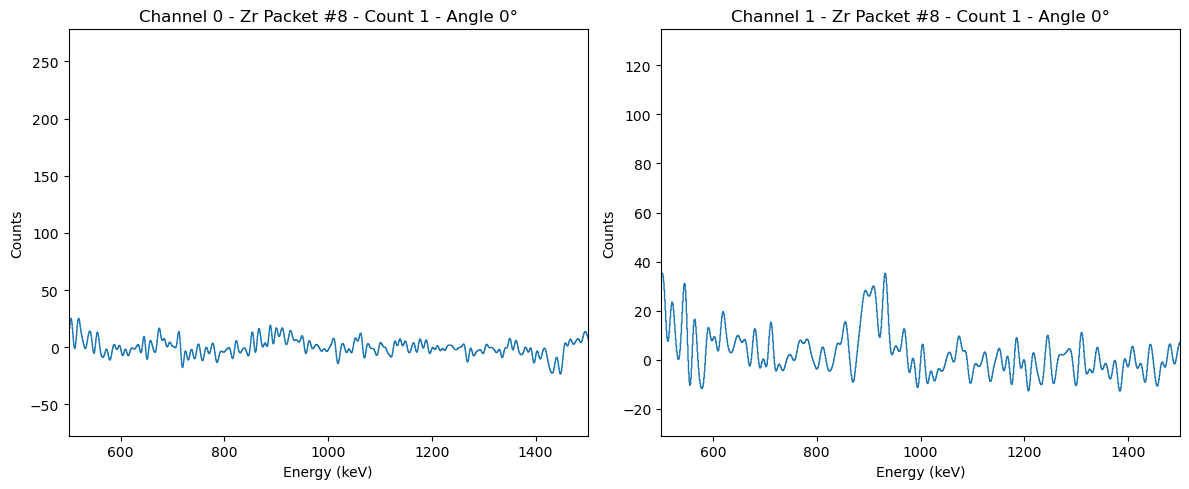

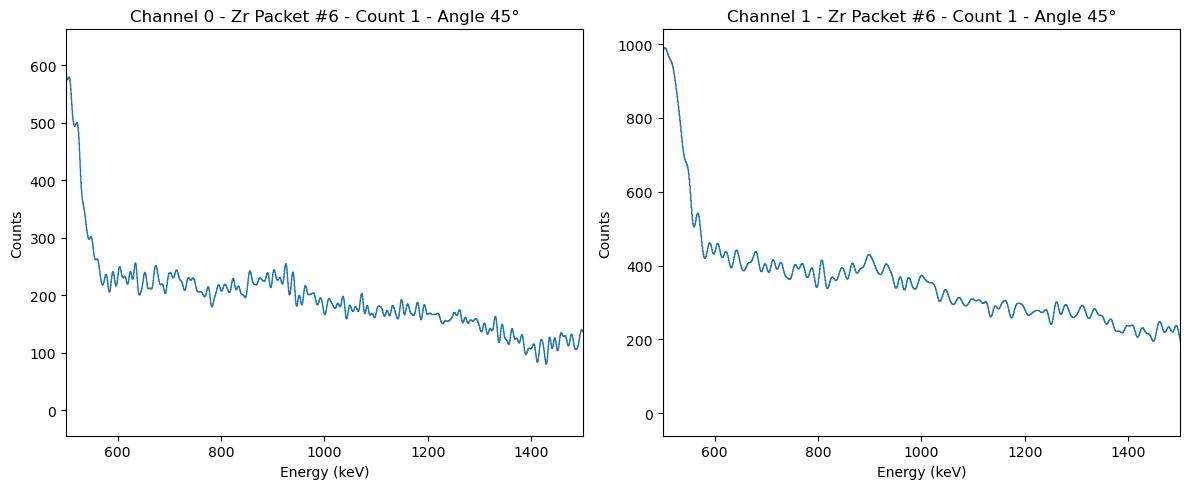

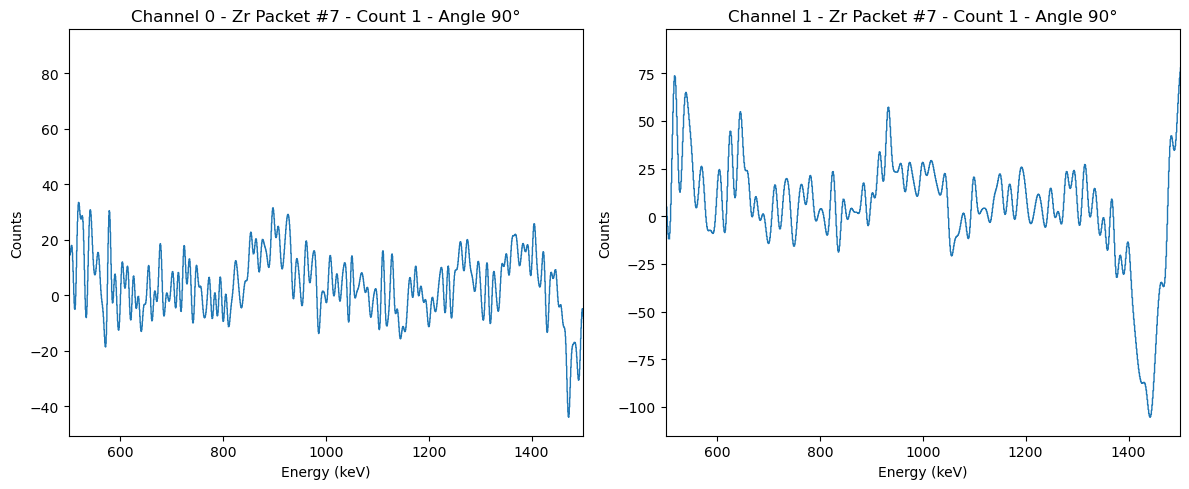

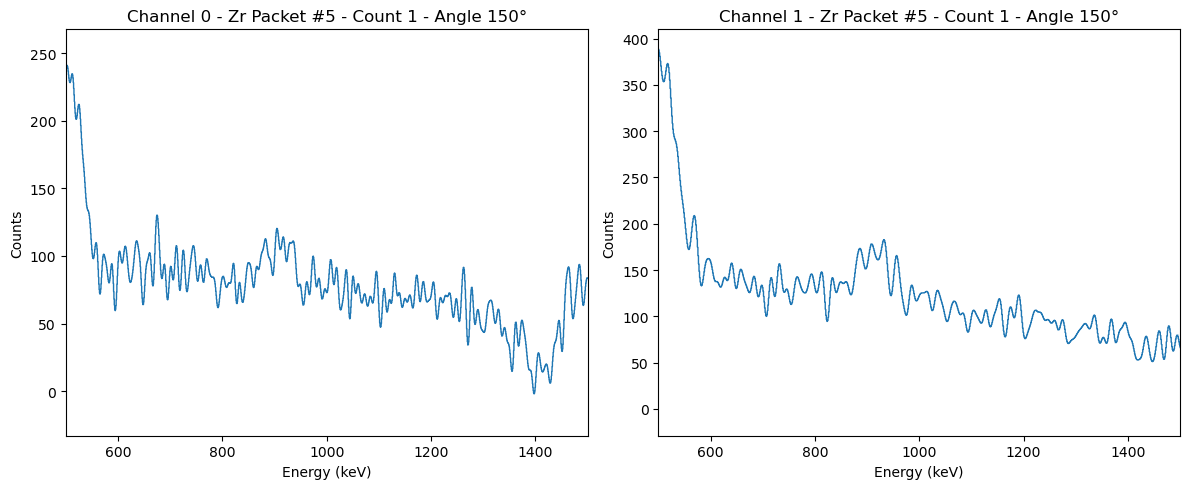

In [ ]:
# plot the activation foil gamma spectra


for name, measurements in foil_measurements.items():
    angle = measurements['foil'].angle
    print(measurement)
    for count_num, measurement in measurements['measurements'].items():
        fig, axes = plt.subplots(nrows=1, ncols=len(measurement.detectors), figsize=(12, 5))
        if not isinstance(axes, np.ndarray):
            axes = [axes]
        for d, detector in enumerate(measurement.detectors):
            background_detector = background_meas.get_detector(detector.channel_nb)
            hist, bin_edges = detector.get_energy_hist_background_substract(
                background_detector, bins=None
            )
            filtered_hist = signal.filtfilt(b, a, hist)

            calibrated_bin_edges = np.polyval(
                calibration_coeffs[detector.channel_nb], bin_edges
            )
            axes[d].stairs(
                filtered_hist,
                calibrated_bin_edges,
            )
            axes[d].set_xlabel("Energy (keV)")
            axes[d].set_ylabel("Counts")
            axes[d].set_title(f"Channel {detector.channel_nb} - {name} - Count {count_num} - Angle {angle}°")
            axes[d].set_xlim(500, 1500)
        fig.tight_layout()




In [ ]:
from process_foil_data import calculate_neutron_rate_from_foil

for foil_name in foil_measurements.keys():
    print(f"\nProcessing foil: {foil_name}")
    gamma_energy = foil_measurements[foil_name]['foil'].reaction.product.energy
    print(gamma_energy)
    nuclide = foil_measurements[foil_name]['foil'].reaction.reactant.name
    angle = foil_measurements[foil_name]['foil'].angle
    if foil_rates.get(nuclide) is None:
        foil_rates[nuclide] = {}
        foil_rates_err[nuclide] = {}
    if foil_rates[nuclide].get(angle) is None:
        foil_rates[nuclide][angle] = []
        foil_rates_err[nuclide][angle] = []

    if all_foil_rates.get(angle) is None:
        all_foil_rates[angle] = []
        all_foil_rates_err[angle] = []
    detector_efficiency = {}
    detector_efficiency_err = {}
    for ch in channels:
        detector_efficiency[ch], detector_efficiency_err[ch] = \
            calculate_efficiency_at_energy(energy, ch, method='propagation')

    print('\nWith Detector Efficiency Error:')

    neutron_rates, neutron_rates_err = calculate_neutron_rate_from_foil(
                                        foil_measurements,
                                        foil_name,
                                        background_meas,
                                        calibration_coeffs,
                                        efficiency_coeffs,
                                        search_width=search_width,
                                        detector_efficiency=detector_efficiency,
                                        detector_efficiency_err=detector_efficiency_err
                                        )


    for count_name in neutron_rates.keys():
        print(count_name)
        for ch in np.sort(list(neutron_rates[count_name].keys())):
            neutron_rate = neutron_rates[count_name][ch]
            neutron_rate_err = neutron_rates_err[count_name][ch]
            print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
            if neutron_rate[0] > 0:

                all_foil_rates[angle].append(neutron_rate[0])
                all_foil_rates_err[angle].append(neutron_rate_err[0])
                foil_rates[nuclide][angle].append(neutron_rate[0])
                foil_rates_err[nuclide][angle].append(neutron_rate_err[0])
            else:
                print("Negative rate value, skipping addition to totals.")


# print('\nWithout Detector Efficiency Error:')

# neutron_fluxs, neutron_flux_errs = calculate_neutron_flux_from_foil(
#                                     foil_measurements,
#                                     foil_name,
#                                     background_meas,
#                                     calibration_coeffs,
#                                     efficiency_coeffs,
#                                     search_width=search_width,
#                                     detector_efficiency=detector_efficiency,
#                                     detector_efficiency_err=0.0
#                                     )

# for count_name in neutron_rates.keys():
#     print(count_name)
#     for ch in np.sort(list(neutron_rates[count_name].keys())):
#         neutron_rate = neutron_rates[count_name][ch]
#         neutron_rate_err = neutron_rate_errs[count_name][ch]
#         print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")



Processing foil: Nb Packet #7
[934.44]

With Detector Efficiency Error:
Count 1
	 Ch 0: Neutron rate: 1.724e+09 +/- 6.415e+07 n/s
	 Ch 1: Neutron rate: -4.965e+09 +/- nan n/s
Negative rate value, skipping addition to totals.
Count 2
	 Ch 0: Neutron rate: 1.095e+09 +/- 4.336e+07 n/s
	 Ch 1: Neutron rate: 1.742e+09 +/- 6.060e+07 n/s

Processing foil: Nb Packet #4
[934.44]

With Detector Efficiency Error:
Count 1
	 Ch 0: Neutron rate: 1.952e+09 +/- 7.229e+07 n/s
	 Ch 1: Neutron rate: 2.958e+09 +/- 9.961e+07 n/s

Processing foil: Nb Packet #5
[934.44]

With Detector Efficiency Error:
Count 1
	 Ch 0: Neutron rate: 1.945e+09 +/- 7.305e+07 n/s
	 Ch 1: Neutron rate: 2.335e+09 +/- 8.111e+07 n/s
Count 2
	 Ch 0: Neutron rate: 1.503e+09 +/- 5.579e+07 n/s
	 Ch 1: Neutron rate: 1.704e+09 +/- 5.911e+07 n/s

Processing foil: Nb Packet #3
[934.44]

With Detector Efficiency Error:
Count 1
	 Ch 0: Neutron rate: 3.022e+09 +/- 1.087e+08 n/s
	 Ch 1: Neutron rate: 2.769e+09 +/- 9.601e+07 n/s

Processing foi

## Angular Characterization Results

In [ ]:
# Remmove outliers based on a simple threshold
for angle in all_foil_rates.keys():
    rates = np.array(all_foil_rates[angle])
    rates_err = np.array(all_foil_rates_err[angle])
    mean_rate = np.mean(rates)
    std_rate = np.std(rates)
    threshold = 2 * std_rate  # 2-sigma threshold
    filtered_rates = []
    filtered_rates_err = []
    for f, fe in zip(rates, rates_err):
        if abs(f - mean_rate) <= threshold:
            filtered_rates.append(f)
            filtered_rates_err.append(fe)
        else:
            print(f"Outlier detected at angle {angle}°: {f:.3e} n/cm^2/s")
    for material in foil_rates.keys():
        for i, f in enumerate(foil_rates[material][angle]):
            if abs(f - mean_rate) > threshold:
                print(f"Outlier detected for material {material} at angle {angle}°: {f:.3e} n/cm^2/s")
                del foil_rates[material][angle][i]
                del foil_rates_err[material][angle][i]
    all_foil_rates[angle] = filtered_rates
    all_foil_rates_err[angle] = filtered_rates_err

Outlier detected at angle 90°: 9.393e+09 n/cm^2/s
Outlier detected for material Zr90 at angle 90°: 9.393e+09 n/cm^2/s


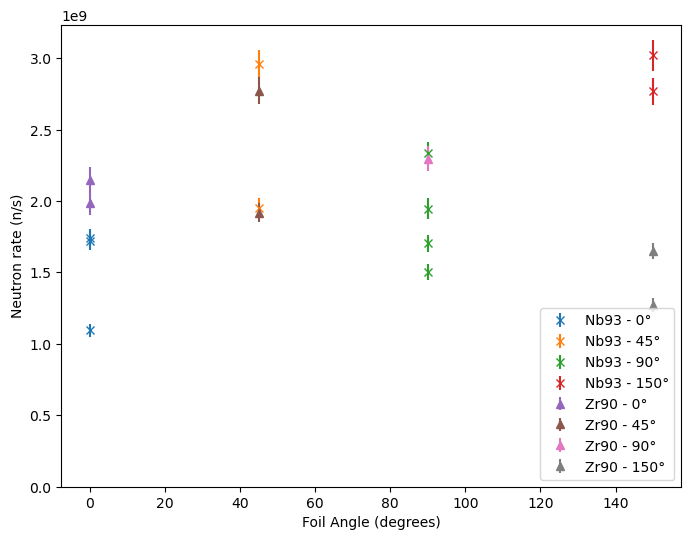

In [ ]:
fig, axes = plt.subplots(figsize=(8,6))
formats = {'Nb93': 'x',
           'Zr90': '^',}
for foil_type in foil_rates.keys():
    for angle in foil_rates[foil_type].keys():
        axes.errorbar(
            [angle]*len(foil_rates[foil_type][angle]),
            foil_rates[foil_type][angle],
            yerr=foil_rates_err[foil_type][angle],
            fmt=formats.get(foil_type, 'o'),
            label=f"{foil_type} - {angle}°"
        )
axes.set_xlabel("Foil Angle (degrees)")
axes.set_ylabel("Neutron rate (n/s)")
axes.set_ylim(bottom=0)
axes.legend()

In [ ]:
import json
processed_data_file = "../../data/processed_data.json"

processed_data = {'foils': 
                       {'NaI': {}
                  }
}
for foil_type in foil_rates.keys():
    processed_data['foils']['NaI'][foil_type] = {}
    for angle in foil_rates[foil_type].keys():
        processed_data['foils']['NaI'][foil_type][angle] = {
            'rate': np.mean(foil_rates[foil_type][angle]),
            'rate_err': np.sqrt(np.sum(np.square(foil_rates_err[foil_type][angle]))) / len(foil_rates_err[foil_type][angle]),
            'units': 'n/s',
            'number_of_measurements': len(foil_rates[foil_type][angle])
        }


try:
    with open(processed_data_file, "r") as f:
        existing_data = json.load(f)
except FileNotFoundError:
    print(f"Processed data file not found, creating it in {processed_data_file}")
    existing_data = {}

existing_data.update(processed_data)

with open(processed_data_file, "w") as f:
    json.dump(existing_data, f, indent=4)

print(f"Processed data stored in {processed_data_file}")

Processed data stored in ../../data/processed_data.json
